In [1]:
from sklearn.datasets import load_iris
import numpy as np
import matplotlib.pyplot as plt

# PCA
In this notebook, you will implement Principal Component Analysis (PCA).
For a change, let us use the iris dataset, which can be obtained using the `load_iris` function from `sklearn`

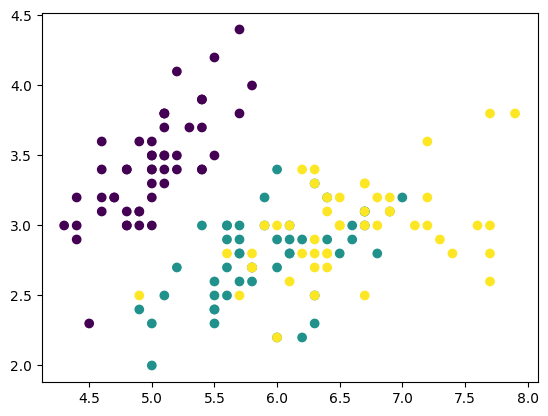

In [7]:
iris = load_iris(as_frame=False)
X = np.array(iris.data)
y = iris.target

# TODO: make a scatter plot like the one shown below
plt.scatter(X[:, 0], X[:, 1], c=y)#, cmap='viridis')
plt.show()

Implement a function performing PCA. 
Remember the necessary steps!

In [30]:
def my_pca(X, n_components=None):
    X_centered = X - np.mean(X, axis=0)

    
    cov_matrix = np.cov(X_centered, rowvar=False) # FIX 1: rowvar=False für Merkmale in Spalten, X sind Spalten

    eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
    sorted_indices = np.argsort(eigenvalues)[::-1]
    sorted_eigenvalues = eigenvalues[sorted_indices]
    sorted_eigenvectors = eigenvectors[:, sorted_indices]

    Q = sorted_eigenvectors[:, :n_components]

    # FIX 2: richtige Projektion
    X_red = X_centered @ Q

    expl_variance = sorted_eigenvalues[:n_components] / np.sum(sorted_eigenvalues) #explained variance see definition

    return X_red, Q, expl_variance

    

### Explained Variance (Erklärte Varianz)

Die erklärte Varianz gibt an, wie viel Prozent der Gesamtvarianz der Daten
durch jede Hauptkomponente (Principal Component) erklärt wird.

- Jeder Eigenwert λᵢ der Kovarianzmatrix entspricht der Varianz entlang der
  i-ten Hauptkomponente.
- Die explained variance ratio wird berechnet als:


- **Wichtig:**  
Wenn *alle* Hauptkomponenten betrachtet werden, summieren sich die
explained variance ratios immer zu **1**, da die gesamte Varianz der Daten
abgedeckt ist.

- Wenn nur die ersten *k* Komponenten genutzt werden (für Dimensionalitätsreduktion),
ergibt die Summe der explained variance nur einen Wert **< 1**, weil die Varianz
der ausgelassenen Komponenten fehlt.

Dies hilft zu beurteilen, wie viel Information die reduzierten Dimensionen enthalten.


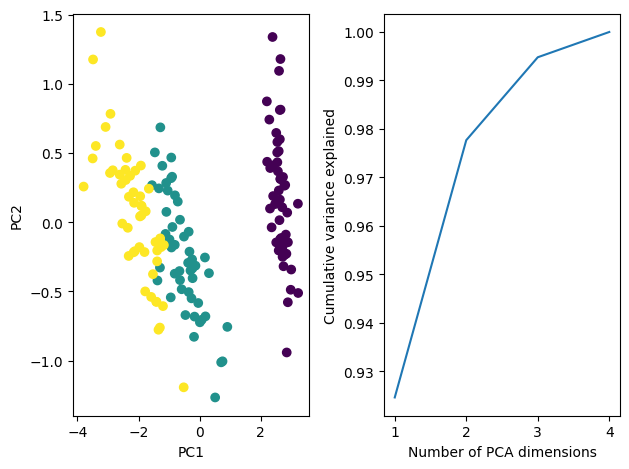

In [29]:
X_red, Q, expl_variance = my_pca(X)

fig, axs = plt.subplots(1,2)
axs[0].scatter(X_red[:,0], X_red[:,1], c=y)
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")

axs[1].plot(np.arange(1,5), np.cumsum(expl_variance))
axs[1].set_xlabel("Number of PCA dimensions")
axs[1].set_ylabel("Cumulative variance explained")
plt.tight_layout()
plt.show()

Alternatively, you can use the `sklearn` class.

Try it below:

In [27]:
from sklearn.decomposition import PCA
m = PCA(n_components = 2).fit(X)
X_reduced = m.transform(X)
print(np.cumsum(m.explained_variance_ratio_))

[0.92461872 0.97768521]


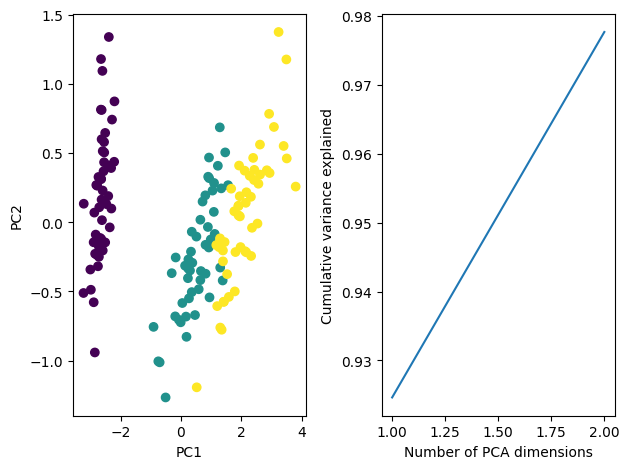

In [28]:
fig, axs = plt.subplots(1, 2)

# Scatterplot der ersten beiden PCs
axs[0].scatter(X_reduced[:, 0], X_reduced[:, 1], c=y)
axs[0].set_xlabel("PC1")
axs[0].set_ylabel("PC2")

# Korrekte x-Achse: 1 ... n_components
axs[1].plot(np.arange(1, len(m.explained_variance_ratio_) + 1), np.cumsum(m.explained_variance_ratio_))
axs[1].set_xlabel("Number of PCA dimensions")
axs[1].set_ylabel("Cumulative variance explained")

plt.tight_layout()
plt.show()
